In [70]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model


### Cargamos el dataset

In [71]:
df = pd.read_csv('titanic.csv')
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df = pd.get_dummies(df)
del df['Sex_female']
df['Age'] = df['Age'].fillna(df.Age.mean())

# Target sin nada

In [72]:
df.Survived.mean()

0.3838383838383838

### Creamos un modelo

In [73]:
target = 'Survived'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

model = linear_model.LogisticRegression()
model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
predicciones = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_pred=predicciones, y_true=y_test)

0.8022388059701493

### Matriz de confusion

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


- TP (Verdaderos Positivos): Casos positivos correctamente clasificados.

- FN (Falsos Negativos): Casos positivos incorrectamente clasificados como negativos.

- FP (Falsos Positivos): Casos negativos incorrectamente clasificados como positivos.

- TN (Verdaderos Negativos): Casos negativos correctamente clasificados.

In [18]:
# Crea una matriz de confusión con Sklearn
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_pred=predicciones, y_true=y_test)


### Sensitivity 

Dentro de los que si sobreviven, que porcentaje predice bien el modelo

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


$$\text{Sensitivity} = \frac{\text{True positive (TP)}}{\text{True positive (TP)} + \text{False Negative (FN)}}$$

In [20]:
cf_matrix

array([[143,  25],
       [ 28,  72]])

In [21]:
cf_matrix[0][0] / (cf_matrix[0][0] + cf_matrix[0][1])

0.8511904761904762

### Especificidad 

De los que no sobreviven, que porcentaje predice bien el modelo 

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


$$\text{Specificity} = \frac{\text{True Negative (TN)}}{\text{True Negative (TN)} + \text{False Positive (FP)}}$$


In [22]:
cf_matrix[1][1] / (cf_matrix[1][0] + cf_matrix[1][1])

0.72

### Recrea la matriz de confusión, calcula sensitivity y specificity con un corte de 0.7

In [24]:
probabilidades = model.predict_proba(X_test)[:,1]
predicciones_07 = np.where(probabilidades > 0.7, True, False)

In [28]:
cf_matrix1 = confusion_matrix(y_pred=predicciones_07, y_true=y_test)

In [30]:
# Sensitivity = TP / (TP + FN)
cf_matrix1[0][0] / (cf_matrix1[0][0] + cf_matrix1[0][1])

0.9642857142857143

In [31]:
# Specificity = TN / (TN + FP)
cf_matrix1[1][1] / (cf_matrix1[1][1] + cf_matrix1[1][0])

0.5

### Siempre habrá un balance entre sensitivity y specificity en la elección de los cortes 



In [8]:
# Calcular para varios valores 


### Utiliza sklearn para obtener esta curva

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, umbrales = roc_curve(y_true=y_test, y_score=probabilidades)


# FPR : De los que realmente eran negativos, ¿qué % predije incorrectamente como positivos?

# TPR : de los que dije que eran ppsitivos, que % predije correctamente

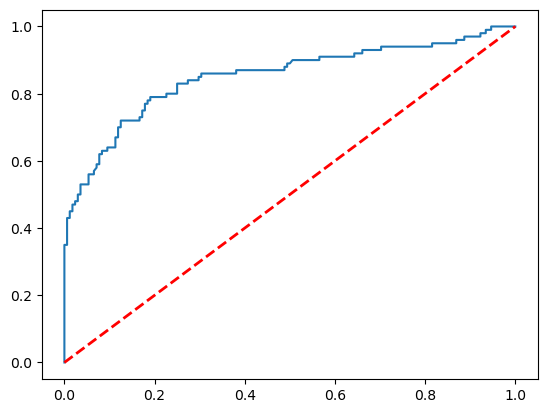

In [52]:
# fpr, tpr
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

### Definición, el AUC es el área del gráfico anterior que está bajo la linea (área bajo la curva)

Si se toman dos datos al azar, uno que sobrevive y otro que no sobrevive, ¿cuál es la probabilidad de que el que sobrevive tenga mayor probabilidad predicha?



In [53]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_score=probabilidades, y_true=y_test)


0.8507142857142856

### Calcula el AUC de una regresión polinomial grado 2

In [54]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV



### Compara las dos ROC curves

### KNN clasificación, cross validation de vecions más cercanos con AUC

In [55]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
knn_prob = model_knn.predict_proba(X_test)[:,1]

In [61]:
roc_auc_score(y_score=knn_prob, y_true=y_test)

0.7369940476190477

In [58]:
fpr_knn, tpr_knn, umbrales = roc_curve(y_true=y_test, y_score=knn_prob)

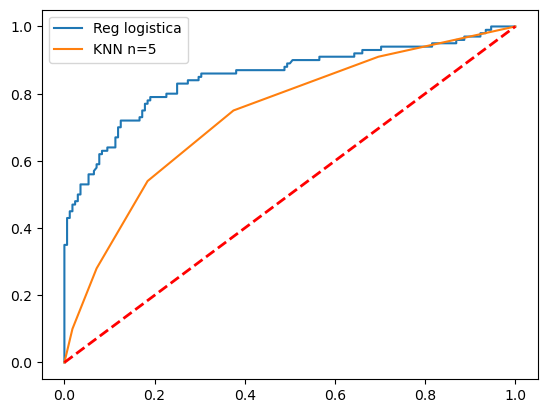

In [63]:
# fpr, tpr
plt.plot(fpr, tpr, label="Reg logistica")
plt.plot(fpr_knn, tpr_knn, label="KNN n=5")
plt.legend()
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

## Intuitivamente, que es el AUC

Si tomas dos personas, una que sobrevive y otra que no

*El AUC es la probabilidad de que la persona que sobrevive, tiene una predicción más alta*




In [110]:
auc_df = pd.DataFrame({
    'prob': probabilidades,
#    'prob_knn': knn
    'y_test': y_test
})
resultado = []
for i in range(1,1000):
    no_sobrevive_al_azar = auc_df.query('y_test == 0').sample(1)
    sobrevive_al_azar = auc_df.query('y_test == 1').sample(1)

    # score no sobrevive
    score_mayor = sobrevive_al_azar.prob.values > no_sobrevive_al_azar.prob.values

    # Guardamos rel resultado
    resultado.append(score_mayor)

In [111]:
np.mean(resultado)

0.8588588588588588